In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from impulse.experimental import BirthDeathProductSpace
from impulse.diagnostics import model_visitation_stats, bayes_factor_from_chain
from impulse.nuts.core import NUTSState, nuts_step
from impulse.nuts.mass_matrix import MassMatrix, MassMatrixType
from impulse.nuts.warmup import find_reasonable_step_size

%matplotlib inline

# Hybrid RJMCMC + NUTS + Parallel Tempering: Trans-Dimensional Sinusoid Detection

This notebook demonstrates a hybrid sampling scheme that combines:

1. **RJMCMC** (Reversible-Jump MCMC) for **between-model moves** — birth/death proposals that add or remove sinusoidal sources
2. **NUTS** (No-U-Turn Sampler) for **within-model moves** — efficient gradient-based exploration of the continuous parameter space
3. **Parallel Tempering** for **improved mixing** — multiple chains at different temperatures with periodic swap attempts to help the sampler escape local modes and explore model space more freely

Each iteration of the sampler runs on all temperature chains:
1. Proposes a model change via RJMCMC (birth, death, or source swap) with tempered acceptance
2. Performs a NUTS step on the active continuous parameters using the tempered gradient
3. Every few iterations, attempts to swap states between adjacent temperature chains

Hot chains (high T) accept model dimension changes more easily since the likelihood is dampened. PT swaps propagate these configurations to the cold chain (T=1), which provides the final posterior samples.

**Problem**: Given noisy time-series data containing 12 sinusoids with amplitudes spanning two orders of magnitude, determine how many sinusoidal components are present and estimate their parameters.

## Generate Synthetic Data

We inject 12 sinusoids with varying amplitudes. The first 8 have SNR > 4 and should be detectable by Bayesian model selection; the last 4 have SNR < 3 and should remain below the detection threshold (the Occam penalty from the prior volume exceeds the likelihood improvement).

In [2]:
rng_data = np.random.default_rng(42)

N_pts = 500
t = np.linspace(0, 10, N_pts)
sigma = 1.0

# 12 true sinusoids: [amplitude, frequency (Hz), phase (rad)]
true_sources = np.array([
    # Strong (SNR > 10)
    [2.50, 0.30, 1.20],
    [2.00, 0.75, 0.50],
    [1.50, 1.40, 2.30],
    [1.20, 2.10, 1.00],
    # Moderate (SNR 4-11)
    [0.70, 0.50, 0.80],
    [0.50, 1.80, 2.50],
    [0.40, 2.80, 0.30],
    [0.30, 3.50, 1.50],
    # Weak (SNR < 3, likely undetectable)
    [0.15, 1.10, 2.10],
    [0.10, 2.50, 0.70],
    [0.07, 3.20, 1.80],
    [0.04, 4.20, 2.80],
])
n_true = len(true_sources)

signal = np.zeros(N_pts)
for A, f, phi in true_sources:
    signal += A * np.sin(2 * np.pi * f * t + phi)

data = signal + sigma * rng_data.standard_normal(N_pts)

# Print source table with SNR
snr_values = true_sources[:, 0] * np.sqrt(N_pts / 2) / sigma
print(f'{"Source":>6s}  {"A":>5s}  {"f (Hz)":>6s}  {"phase":>5s}  {"SNR":>6s}  Category')
print('-' * 55)
for i, ((A, f, phi), snr) in enumerate(zip(true_sources, snr_values)):
    cat = 'strong' if snr > 10 else ('moderate' if snr > 3 else 'weak')
    print(f'  {i+1:>4d}  {A:5.2f}  {f:6.2f}  {phi:5.2f}  {snr:6.1f}  {cat}')

Source      A  f (Hz)  phase     SNR  Category
-------------------------------------------------------
     1   2.50    0.30   1.20    39.5  strong
     2   2.00    0.75   0.50    31.6  strong
     3   1.50    1.40   2.30    23.7  strong
     4   1.20    2.10   1.00    19.0  strong
     5   0.70    0.50   0.80    11.1  strong
     6   0.50    1.80   2.50     7.9  moderate
     7   0.40    2.80   0.30     6.3  moderate
     8   0.30    3.50   1.50     4.7  moderate
     9   0.15    1.10   2.10     2.4  weak
    10   0.10    2.50   0.70     1.6  weak
    11   0.07    3.20   1.80     1.1  weak
    12   0.04    4.20   2.80     0.6  weak


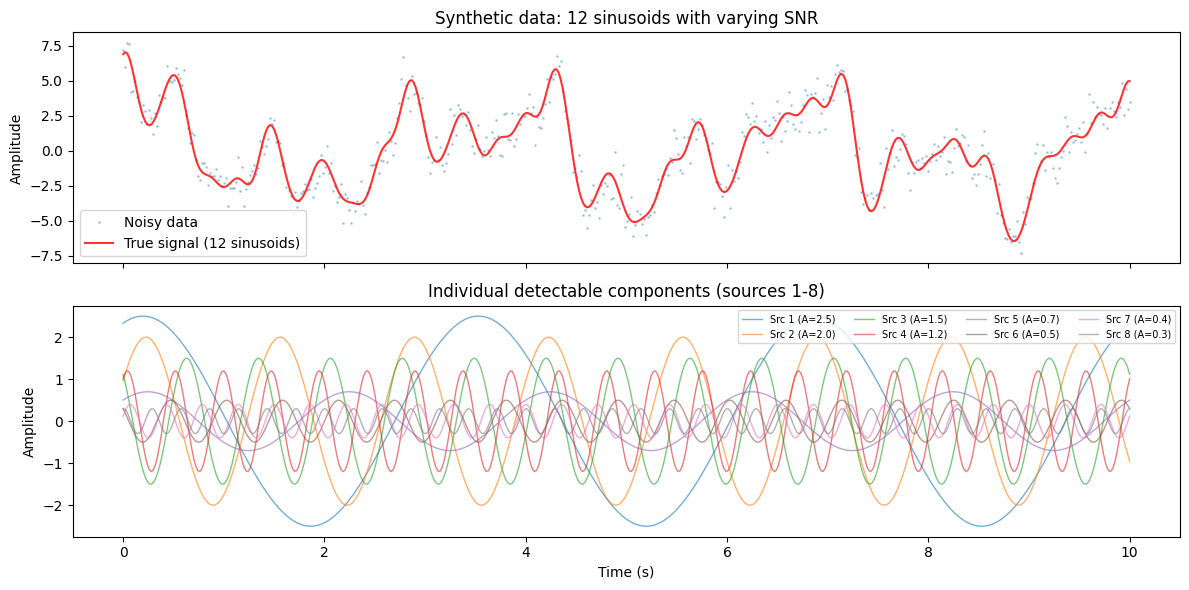

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(t, data, '.', alpha=0.3, ms=2, label='Noisy data')
axes[0].plot(t, signal, 'r-', lw=1.5, alpha=0.8, label=f'True signal ({n_true} sinusoids)')
axes[0].set_ylabel('Amplitude')
axes[0].legend()
axes[0].set_title('Synthetic data: 12 sinusoids with varying SNR')

for i, (A, f, phi) in enumerate(true_sources[:8]):
    comp = A * np.sin(2 * np.pi * f * t + phi)
    axes[1].plot(t, comp, alpha=0.6, lw=1, label=f'Src {i+1} (A={A})')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Amplitude')
axes[1].legend(fontsize=7, ncol=4, loc='upper right')
axes[1].set_title('Individual detectable components (sources 1-8)')
plt.tight_layout()

## Model Definition

Each sinusoidal source has 3 parameters: amplitude $A$, frequency $f$, and phase $\phi$. The model with $k$ active sources is:

$$\text{model}(t) = \sum_{i=1}^{k} A_i \sin(2\pi f_i t + \phi_i)$$

We use uniform priors on all parameters and a Gaussian likelihood. The product space has `30 sources * 3 params + 1 model index = 91` dimensions. The gradient of the log-likelihood is computed analytically for efficient NUTS transitions.

In [4]:
MAX_SOURCES = 30
NUM_PARAMS = 3  # (amplitude, frequency, phase) per source

# Prior bounds
A_MIN, A_MAX = 0.0, 5.0
F_MIN, F_MAX = 0.01, 5.0
PHI_MIN, PHI_MAX = 0.0, 2 * np.pi


def source_prior_draw(rng):
    """Draw one source's parameters from the prior."""
    return np.array([
        rng.uniform(A_MIN, A_MAX),
        rng.uniform(F_MIN, F_MAX),
        rng.uniform(PHI_MIN, PHI_MAX),
    ])


def log_prior(params):
    """Uniform prior on ALL source parameters (active + inactive)."""
    n = len(params) // NUM_PARAMS
    if n == 0:
        return 0.0
    p = params.reshape(n, NUM_PARAMS)
    if (np.any(p[:, 0] < A_MIN) or np.any(p[:, 0] > A_MAX)
        or np.any(p[:, 1] < F_MIN) or np.any(p[:, 1] > F_MAX)
        or np.any(p[:, 2] < PHI_MIN) or np.any(p[:, 2] > PHI_MAX)):
        return -np.inf
    return 0.0


def log_likelihood(params):
    """Gaussian likelihood for sinusoidal model (vectorized over sources)."""
    n = len(params) // NUM_PARAMS
    if n == 0:
        return -0.5 * np.sum((data / sigma) ** 2)
    p = params.reshape(n, NUM_PARAMS)
    arg = 2 * np.pi * np.outer(p[:, 1], t) + p[:, 2, None]
    model = np.sum(p[:, 0, None] * np.sin(arg), axis=0)
    return -0.5 * np.sum(((data - model) / sigma) ** 2)


def loglike_and_grad(active_params):
    """Log-likelihood and analytical gradient for active sources.

    Gradient is vectorized: no Python loops over sources or data points.
    """
    n = len(active_params) // NUM_PARAMS
    if n == 0:
        return -0.5 * np.sum((data / sigma) ** 2), np.array([])

    p = active_params.reshape(n, NUM_PARAMS)
    A, f, phi = p[:, 0], p[:, 1], p[:, 2]

    arg = 2 * np.pi * np.outer(f, t) + phi[:, None]   # (n, N_pts)
    sin_arg = np.sin(arg)
    cos_arg = np.cos(arg)

    model = np.sum(A[:, None] * sin_arg, axis=0)       # (N_pts,)
    residual = data - model
    loglike = -0.5 * np.sum((residual / sigma) ** 2)

    r_s2 = residual / sigma ** 2                        # (N_pts,)
    grad = np.empty_like(active_params)
    # d logL / d A_i = sum_j residual_j * sin(arg_ij) / sigma^2
    grad[0::3] = sin_arg @ r_s2
    # d logL / d f_i = sum_j residual_j * A_i * 2*pi*t_j * cos(arg_ij) / sigma^2
    grad[1::3] = (A[:, None] * (2 * np.pi * t[None, :]) * cos_arg) @ r_s2
    # d logL / d phi_i = sum_j residual_j * A_i * cos(arg_ij) / sigma^2
    grad[2::3] = (A[:, None] * cos_arg) @ r_s2

    return loglike, grad

In [5]:
space = BirthDeathProductSpace(
    loglikelihood=log_likelihood,
    logprior=log_prior,
    num_sources=MAX_SOURCES,
    num_params=NUM_PARAMS,
    source_prior_draw=source_prior_draw,
)

print(f'Product space: {space.ndim} dimensions')
print(f'  {MAX_SOURCES} sources x {NUM_PARAMS} params/source + 1 model index')

Product space: 91 dimensions
  30 sources x 3 params/source + 1 model index


## Hybrid RJMCMC + NUTS Sampler with Parallel Tempering

Each iteration of the hybrid sampler runs on **multiple temperature chains** simultaneously:

1. **RJMCMC phase**: Propose a model change on each chain with tempered acceptance (likelihood scaled by 1/T).
   - **Birth/death** (80%): the *combined* kernel selects birth vs death internally with the model-index-dependent schedule probabilities, then either adds a source drawn from the prior or removes a randomly chosen active source (refreshing the vacated slot from the prior).  Registering birth and death as separate constant-weight moves violates detailed balance and biases the model posterior.
   - **Source swap** (20%): Swap parameters between two sources

2. **NUTS phase**: Take a gradient-based NUTS step on the active continuous parameters of each chain, using the tempered log-posterior gradient.

3. **Parallel Tempering swaps** (every few iterations): Attempt to swap states between adjacent temperature chains. Hot chains (high T) explore model space more freely — birth/death moves are more easily accepted when the likelihood is dampened. PT swaps propagate these model configurations to the cold chain (T=1), which provides the posterior samples.

Step sizes are found automatically per (chain, model dimension) pair and cached. Hot chains use a smaller maximum tree depth for efficiency.

In [ ]:
class _ProposalAdapter:
    """Minimal adapter for RJMCMC proposals (they need .rng and .current_sample)."""
    def __init__(self, rng):
        self.rng = rng
        self.current_sample = None


def hybrid_rjnuts_pt_sample(space, initial_position, num_iterations,
                             ntemps=5, max_temp=50.0, swap_every=5,
                             max_tree_depth=8, seed=42):
    """Alternating RJMCMC + NUTS sampler with parallel tempering.

    Each iteration:
    1. RJMCMC step on all chains (tempered acceptance)
    2. NUTS step on all chains (tempered gradient)
    3. Every swap_every iterations, attempt PT swaps between adjacent chains

    Parameters
    ----------
    space : BirthDeathProductSpace
    initial_position : np.ndarray
    num_iterations : int
    ntemps : int
        Number of temperature chains.
    max_temp : float
        Maximum temperature for the hottest chain.
    swap_every : int
        Attempt PT swaps every this many iterations.
    max_tree_depth : int
        Maximum NUTS tree depth (reduced for hot chains).
    seed : int

    Returns
    -------
    dict with chain, logp, tree_depth, divergent, rjmcmc_accepted,
         nmodel_chains, temps, swap_rates.
    """
    rng = np.random.default_rng(seed)
    ndim = space.ndim
    num_params = space.num_params

    # Geometric temperature ladder
    temps = np.geomspace(1.0, max_temp, ntemps)
    print(f'Temperature ladder ({ntemps} chains): '
          f'{np.array2string(temps, precision=2, separator=", ")}')

    # Initialize all chains from the same starting point
    states = np.tile(initial_position, (ntemps, 1))
    loglikes = np.array([space.get_loglikelihood(states[k]) for k in range(ntemps)])
    logpriors = np.array([space.get_logprior(states[k]) for k in range(ntemps)])

    # RJMCMC proposals (shared across chains, used sequentially).
    # Birth and death are ONE combined kernel: it selects birth vs death
    # internally with the schedule probabilities, which is what keeps
    # detailed balance under the constant selection weights used below.
    # (Registering them as separate constant-weight moves — the old
    # 40/40/20 pattern — biases the model posterior.)
    birth_death = space.get_birth_death_proposal()
    swap_prop = space.get_source_swap_proposal()
    adapter = _ProposalAdapter(rng)

    # Per-(chain, model) caches for NUTS step sizes
    step_cache = {}
    mm_cache = {}

    # Swap tracking
    swap_accepts = np.zeros(ntemps - 1)
    n_swap_rounds = 0

    # Storage (cold chain only, plus model indices for all chains)
    chain = np.zeros((num_iterations, ndim))
    logp_arr = np.zeros(num_iterations)
    tree_depth_arr = np.zeros(num_iterations, dtype=int)
    divergent_arr = np.zeros(num_iterations, dtype=bool)
    rjmcmc_accepted_arr = np.zeros(num_iterations, dtype=bool)
    nmodel_chains = np.zeros((num_iterations, ntemps), dtype=int)

    for i in tqdm(range(num_iterations), desc='Hybrid RJMCMC+NUTS+PT'):
        cold_tree_depth = 0
        cold_divergent = False
        cold_rj_accepted = False

        for k in range(ntemps):
            T = temps[k]

            # ---- RJMCMC step (tempered acceptance) ----
            adapter.current_sample = states[k].copy()

            u = rng.random()
            if u < 0.8:
                proposed, qxy = birth_death(adapter)
            else:
                proposed, qxy = swap_prop(adapter)

            ll_proposed = space.get_loglikelihood(proposed)
            lp_proposed = space.get_logprior(proposed)

            # Tempered acceptance: loglike/T + logprior
            log_alpha = ((ll_proposed / T + lp_proposed)
                         - (loglikes[k] / T + logpriors[k]) + qxy)

            rj_accepted = False
            if np.isfinite(log_alpha) and np.log(rng.random()) < log_alpha:
                states[k] = proposed
                loglikes[k] = ll_proposed
                logpriors[k] = lp_proposed
                rj_accepted = True

            if k == 0:
                cold_rj_accepted = rj_accepted

            # ---- NUTS step on active continuous parameters (tempered) ----
            nmodel = int(np.rint(states[k, -1]))
            n_active = (nmodel + 1) * num_params

            if n_active > 0:
                active = states[k, :n_active].copy()
                inactive = states[k, n_active:-1].copy()

                # Tempered logp_and_grad (default-arg capture avoids closure issues)
                def _logp_grad(x, _inact=inactive, _nm=nmodel, _T=T):
                    full = np.concatenate([x, _inact, [_nm]])
                    ll = space.get_loglikelihood(full)
                    lp = space.get_logprior(full)
                    if not np.isfinite(ll + lp):
                        return -np.inf, np.zeros_like(x)
                    _, g = loglike_and_grad(x)
                    return ll / _T + lp, g / _T

                lp_active, g_active = _logp_grad(active)

                if nmodel not in mm_cache:
                    mm_cache[nmodel] = MassMatrix(n_active, MassMatrixType.UNIT)
                mm = mm_cache[nmodel]

                # Smaller tree depth for hot chains (flatter, less depth needed)
                depth_k = max_tree_depth if k == 0 else min(max_tree_depth, 5)

                cache_key = (k, nmodel)
                if cache_key not in step_cache:
                    try:
                        step_cache[cache_key] = find_reasonable_step_size(
                            active, lp_active, g_active, _logp_grad, mm, rng)
                    except Exception:
                        step_cache[cache_key] = 0.01
                    step_cache[cache_key] = float(np.clip(
                        step_cache[cache_key], 1e-6, 1.0))

                ns = NUTSState(
                    position=active, logp=lp_active, grad=g_active,
                    step_size=step_cache[cache_key], mass_matrix=mm)
                ns = nuts_step(ns, _logp_grad, rng, max_tree_depth=depth_k)

                # Write NUTS result back into the full product-space state
                states[k, :n_active] = ns.position
                # Recompute untempered loglike/logprior for PT swaps
                loglikes[k] = space.get_loglikelihood(states[k])
                logpriors[k] = space.get_logprior(states[k])

                if k == 0:
                    cold_tree_depth = ns.tree_depth
                    cold_divergent = ns.divergent

        # ---- PT swap step ----
        if (i + 1) % swap_every == 0:
            for j in reversed(range(ntemps - 1)):
                log_acc = (-loglikes[j] / temps[j]
                           - loglikes[j + 1] / temps[j + 1]
                           + loglikes[j + 1] / temps[j]
                           + loglikes[j] / temps[j + 1])
                if np.log(rng.random()) < log_acc:
                    # Swap entire states between adjacent chains
                    states[[j, j + 1]] = states[[j + 1, j]]
                    loglikes[[j, j + 1]] = loglikes[[j + 1, j]]
                    logpriors[[j, j + 1]] = logpriors[[j + 1, j]]
                    swap_accepts[j] += 1
            n_swap_rounds += 1

        # Record cold chain and all-chain model indices
        chain[i] = states[0]
        logp_arr[i] = loglikes[0] + logpriors[0]
        tree_depth_arr[i] = cold_tree_depth
        divergent_arr[i] = cold_divergent
        rjmcmc_accepted_arr[i] = cold_rj_accepted
        for k in range(ntemps):
            nmodel_chains[i, k] = int(np.rint(states[k, -1]))

    # Report swap statistics
    swap_rates = swap_accepts / max(n_swap_rounds, 1)
    print(f'\nPT swap acceptance rates ({n_swap_rounds} rounds):')
    for j in range(ntemps - 1):
        print(f'  T={temps[j]:.2f} <-> T={temps[j+1]:.2f}: {swap_rates[j]:.1%}')

    return {
        'chain': chain,
        'logp': logp_arr,
        'tree_depth': tree_depth_arr,
        'divergent': divergent_arr,
        'rjmcmc_accepted': rjmcmc_accepted_arr,
        'nmodel_chains': nmodel_chains,
        'temps': temps,
        'swap_rates': swap_rates,
    }

In [ ]:
x0 = space.draw_initial_position(rng_data, nmodel=0)
print(f'Starting from nmodel=0 (1 source)')
print(f'Initial log-posterior: {space.get_loglikelihood(x0) + space.get_logprior(x0):.1f}')

# max_temp=3 gives adjacent temp ratio ~1.32, close to optimal
# 1 + sqrt(2/ndim_eff) for ndim_eff ~ 24 (8 sources x 3 params)
results = hybrid_rjnuts_pt_sample(
    space, x0, num_iterations=15000,
    ntemps=5, max_temp=3.0, swap_every=5, seed=42,
)

cold_chain = results['chain']
cold_logp = results['logp']

## Model Selection Results

The posterior probability over the number of sinusoidal sources tells us how many components the data supports. Sources with SNR > ~4 should be detected; weaker sources are absorbed into the noise.

In [ ]:
burn = 3000
nmodel_samples = np.rint(cold_chain[burn:, -1]).astype(int)

# Posterior model probabilities
probs = np.bincount(nmodel_samples, minlength=MAX_SOURCES) / len(nmodel_samples)
preferred = np.argmax(probs)

print('=== Model Selection ===')
print(f'True number of sinusoids: {n_true}')
print(f'Most probable model:      {preferred + 1} sinusoid(s)')
print()

# Top models
top_models = np.argsort(probs)[::-1]
for k in top_models:
    if probs[k] > 0.001:
        print(f'  P({k+1:2d} sinusoids) = {probs[k]:.3f}')

# Bar chart
fig, ax = plt.subplots(figsize=(10, 4))
model_range = np.arange(MAX_SOURCES)
mask = probs > 0
ax.bar(model_range[mask] + 1, probs[mask], color='steelblue', edgecolor='navy')
ax.axvline(n_true, color='r', ls='--', lw=2, label=f'True count = {n_true}')
ax.set_xlabel('Number of sinusoids')
ax.set_ylabel('Posterior probability')
ax.set_title('Model posterior probabilities')
ax.legend()
plt.tight_layout()

In [ ]:
fig = plt.figure(figsize=(12, 12))
gs = fig.add_gridspec(4, 1, height_ratios=[1.2, 1, 1, 0.7], hspace=0.35)

# Panel 1: Model index for all temperature chains
ax0 = fig.add_subplot(gs[0])
for k in range(len(results['temps'])):
    T = results['temps'][k]
    label = f'T={T:.1f}'
    alpha = 0.9 if k == 0 else 0.35
    lw = 0.6 if k == 0 else 0.4
    ax0.plot(results['nmodel_chains'][:, k] + 1, alpha=alpha, lw=lw, label=label)
ax0.axhline(n_true, color='r', ls='--', lw=1.5, label=f'True = {n_true}')
ax0.axvline(burn, color='k', ls=':', alpha=0.5, label='Burn-in')
ax0.set_ylabel('Num. sources')
ax0.set_title('Model index trace (all temperature chains)')
ax0.legend(fontsize=7, loc='upper right', ncol=4)

# Panel 2: Cold chain log-posterior
ax1 = fig.add_subplot(gs[1], sharex=ax0)
ax1.plot(cold_logp, alpha=0.5, lw=0.5)
ax1.axvline(burn, color='k', ls=':', alpha=0.5)
ax1.set_ylabel('Log-posterior')
ax1.set_title('Cold chain log-posterior')

# Panel 3: NUTS tree depth (cold chain)
ax2 = fig.add_subplot(gs[2], sharex=ax0)
ax2.plot(results['tree_depth'], alpha=0.5, lw=0.5)
ax2.axvline(burn, color='k', ls=':', alpha=0.5)
ax2.set_ylabel('Tree depth')
ax2.set_xlabel('Iteration')
mean_depth = np.mean(results['tree_depth'][burn:])
ax2.set_title(f'Cold chain NUTS tree depth (post burn-in mean = {mean_depth:.1f})')

# Panel 4: PT swap acceptance rates
ax3 = fig.add_subplot(gs[3])
swap_rates = results['swap_rates']
bar_labels = [f'{results["temps"][j]:.1f}\n-\n{results["temps"][j+1]:.1f}'
              for j in range(len(swap_rates))]
bars = ax3.bar(bar_labels, swap_rates, color='steelblue', edgecolor='navy')
ax3.axhline(0.2, color='r', ls='--', alpha=0.5, label='Target (~20%)')
ax3.set_ylabel('Swap rate')
ax3.set_xlabel('Temperature pair')
ax3.set_title('PT swap acceptance rates')
ax3.legend()

plt.tight_layout()

# Summary stats
n_div = np.sum(results['divergent'][burn:])
rj_rate = np.mean(results['rjmcmc_accepted'][burn:])
print(f'Post burn-in NUTS divergences: {n_div}')
print(f'Cold chain RJMCMC acceptance rate: {rj_rate:.1%}')
print(f'Mean NUTS tree depth: {mean_depth:.1f}')

In [ ]:
# Get samples for the most probable model
mask = nmodel_samples == preferred
preferred_samples = cold_chain[burn:][mask]
print(f'=== Parameter recovery ({preferred + 1}-source model, '
      f'{mask.sum()} samples) ===')
print()

# Collect median parameters for each recovered source, sort by frequency
recovered = []
for i in range(preferred + 1):
    A_med = np.median(preferred_samples[:, 3 * i])
    f_med = np.median(preferred_samples[:, 3 * i + 1])
    phi_med = np.median(preferred_samples[:, 3 * i + 2])
    recovered.append([A_med, f_med, phi_med])
recovered = sorted(recovered, key=lambda x: x[1])

true_sorted = sorted(true_sources.tolist(), key=lambda x: x[1])

print(f'{"":>5s}  {"--- Recovered ---":>26s}  |  {"--- Closest true ---":>26s}')
print(f'{"#":>5s}  {"A":>7s} {"f":>7s} {"phi":>7s}  |  '
      f'{"A":>7s} {"f":>7s} {"phi":>7s} {"SNR":>6s}')
print('-' * 72)

for idx, (A_r, f_r, phi_r) in enumerate(recovered):
    # Match to closest true source by frequency
    dists = [abs(f_r - ts[1]) for ts in true_sorted]
    ci = int(np.argmin(dists))
    A_t, f_t, phi_t = true_sorted[ci]
    snr = A_t * np.sqrt(N_pts / 2) / sigma
    print(f'{idx+1:>5d}  {A_r:7.3f} {f_r:7.3f} {phi_r:7.3f}  |  '
          f'{A_t:7.3f} {f_t:7.3f} {phi_t:7.3f} {snr:6.1f}')

In [ ]:
best_idx = np.argmax(cold_logp[burn:]) + burn
best_params = cold_chain[best_idx]
best_nmodel = int(np.rint(best_params[-1]))

best_model = np.zeros(N_pts)
for i in range(best_nmodel + 1):
    A, f, phi = best_params[3*i:3*i+3]
    best_model += A * np.sin(2 * np.pi * f * t + phi)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(t, data, '.', alpha=0.2, ms=2, label='Data')
axes[0].plot(t, signal, 'r-', lw=2, alpha=0.7, label=f'True ({n_true} sinusoids)')
axes[0].plot(t, best_model, 'k--', lw=1.5, label=f'Best fit ({best_nmodel+1} sinusoids)')
axes[0].legend()
axes[0].set_ylabel('Amplitude')
axes[0].set_title('Data and model comparison')

residual = data - best_model
axes[1].plot(t, residual, '.', alpha=0.2, ms=2)
axes[1].axhline(0, color='k', ls='-', alpha=0.3)
axes[1].axhline(sigma, color='r', ls='--', alpha=0.5, label=r'$\pm\sigma$')
axes[1].axhline(-sigma, color='r', ls='--', alpha=0.5)
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Residual')
axes[1].set_title(f'Residuals (RMS = {np.std(residual):.3f})')
axes[1].legend()
plt.tight_layout()

In [ ]:
stats = model_visitation_stats(cold_chain, num_models=MAX_SOURCES, burn=burn)

print('=== Model Visitation Statistics ===')
print()
print('Visit counts and mean dwell times:')
for k in range(MAX_SOURCES):
    if stats['visit_counts'][k] > 0:
        pct = stats['visit_counts'][k] / stats['visit_counts'].sum() * 100
        dwell = stats['mean_dwell_times'][k]
        print(f'  {k+1:2d} sources: {int(stats["visit_counts"][k]):6d} visits '
              f'({pct:5.1f}%), mean dwell = {dwell:.1f} iters')

print()
print(f'=== Bayes Factors (relative to {preferred+1}-source model) ===')
for k in range(MAX_SOURCES):
    if probs[k] > 0.001 and k != preferred:
        bf = probs[preferred] / probs[k]
        print(f'  B({preferred+1} vs {k+1}) = {bf:.1f}')